In [1]:
from notebook_env import *
from tqdm import tqdm
from scipy.stats import binom, betabinom
import scipy.stats

import zipfile
import json
import yaml
from glob import glob

import warnings

def custom_formatwarning(message, category, filename, lineno, file=None, line=None):
    # Customize the output format
    return f'{filename.split("/")[-1]}:{lineno}: {category.__name__}: {message}\n'

# Assign your custom function to formatwarning
warnings.formatwarning = custom_formatwarning

## Parse SWE-Bench data

Parse `metadata.yaml` files:

In [2]:
raw_metadata = {
    f.split('/')[-1]: yaml.safe_load(open(f,'r'))
    for f in glob('./data/swebench/*metadata.yaml')
}

data_df = (
    pd.DataFrame({k:raw_metadata[k]['info'] for k in raw_metadata})
    .T
    .sort_values('resolved')
)
data_df


,logo,mini-swe-agent_version,name,resolved,site,cost,instance_cost,instance_calls
swebench-20250807_mini-v1.7.0_gpt-oss-120b-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.7.0,gpt-oss-120b,26.0,https://platform.openai.com/docs/models/gpt-os...,28.559528,0.057119,27.598
swebench-20250807_mini-v1.7.0_gpt-5-nano-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.7.0,GPT-5 nano (2025-08-07) (medium reasoning),34.8,https://platform.openai.com/docs/models/gpt-5-...,19.03759,0.038075,39.76
swebench-20250726_mini-v1.0.0_o4-mini-2025-04-16-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.0.0,o4-mini (2025-04-16),45.0,https://platform.openai.com/docs/models/o4-mini,104.986666,0.209973,23.278
swebench-20250726_mini-v1.0.0_o3-2025-04-16-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.0.0,o3 (2025-04-16),58.4,https://platform.openai.com/docs/models/o3,166.826374,0.333653,24.698
swebench-20250807_mini-v1.7.0_gpt-5-mini-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.7.0,GPT-5 mini (2025-08-07) (medium reasoning),59.8,https://platform.openai.com/docs/models/gpt-5-...,17.738534,0.035477,14.466
swebench-20250807_mini-v1.7.0_gpt-5-metadata.yaml,[https://upload.wikimedia.org/wikipedia/common...,1.7.0,GPT-5 (2025-08-07) (medium reasoning),65.0,https://platform.openai.com/docs/models/gpt-5,140.191509,0.280383,13.208


Latex summary table:

In [3]:
escape_underscores = lambda s: s.replace('_','\\_')
print('\n'.join(
    f'''
    \\begin{{sc}}{escape_underscores(ind)}\\end{{sc}}
    & {row["name"]}
    & ${row["resolved"]/100:.3g}$
    & ${row["cost"]:.5g}$
    \\\\
    '''.replace('swebench-','').replace('-metadata.yaml','').strip().replace('\n','')
    for i,(ind,row) in enumerate(data_df.iterrows())
))



\begin{sc}20250807\_mini-v1.7.0\_gpt-oss-120b\end{sc}    & gpt-oss-120b    & $0.26$    & $28.56$    \\
\begin{sc}20250807\_mini-v1.7.0\_gpt-5-nano\end{sc}    & GPT-5 nano (2025-08-07) (medium reasoning)    & $0.348$    & $19.038$    \\
\begin{sc}20250726\_mini-v1.0.0\_o4-mini-2025-04-16\end{sc}    & o4-mini (2025-04-16)    & $0.45$    & $104.99$    \\
\begin{sc}20250726\_mini-v1.0.0\_o3-2025-04-16\end{sc}    & o3 (2025-04-16)    & $0.584$    & $166.83$    \\
\begin{sc}20250807\_mini-v1.7.0\_gpt-5-mini\end{sc}    & GPT-5 mini (2025-08-07) (medium reasoning)    & $0.598$    & $17.739$    \\
\begin{sc}20250807\_mini-v1.7.0\_gpt-5\end{sc}    & GPT-5 (2025-08-07) (medium reasoning)    & $0.65$    & $140.19$    \\


Default contract design variables:

In [4]:
mu = data_df['resolved'].map(lambda x: x/100).to_numpy()  # probability of single-test success
c = data_df['cost'].to_numpy()  # probability of single-test success
s = 3  # number of outcomes for initial evaluation
m = 9  # number of outcomes for inspected eval

d = 1000  # Default total cost of inspection
delta = d/(m-1)  # Cost of inspecting a single test
delta

125.0

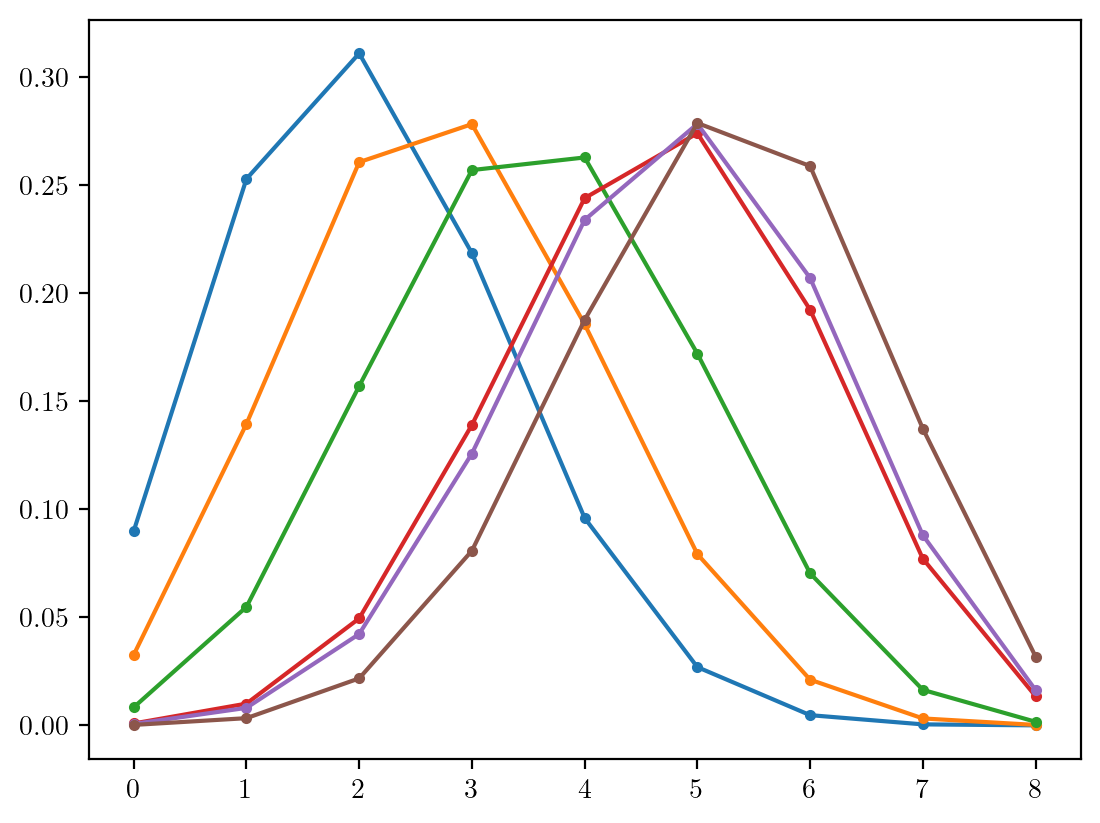

In [5]:
q0 = np.vstack([
    binom.pmf(k=np.arange(s), n=s-1, p=prop)
    for prop in mu
])
q1 = np.vstack([
    binom.pmf(k=np.arange(m), n=m-1, p=prop)
    for prop in mu
])
q = [q1 for k in range(s)]

plt.plot(q1.T,'.-')

## Utility functions

In [6]:
def brute_solve(**kwargs):
    results_lst = []
    q0_arg=kwargs.get('q0',q0)
    s=len(q0_arg[0])
    for p in itertools.product([0,1],repeat=s):
        t,obj = contract_optimization.DiscreteInspectionContractOptimizer.solve_for_fixed_p(
            q0=q0_arg,
            q=kwargs.get('q',q),
            c=kwargs.get('c',c),
            d=np.ones(s)*kwargs.get('d',d),
            p=p,
            target=-1,
        )
        details = {
            'p': p,
            't': t,
            't_support': (t/t.max()>=1e-4).sum(),
            'obj': obj,
            **kwargs,
        }
        for k in ['q0','q']:
            if k in details:
                details.pop(k)
        results_lst.append(details)
    return pd.DataFrame(results_lst)


best_p = lambda df, cols, obj='obj': df.reset_index().pipe(lambda df: df.loc[df.groupby(cols)[obj].idxmin()])


In [7]:
brute_solve()

,p,t,t_support,obj
0,"(0, 0, 0)","[1.6334560666749167e-07, 1.4192275707558833e-0...",1,797.219890
1,"(0, 0, 1)","[1.8477205377178097e-08, -1.4697475053946698e-...",1,638.996598
2,"(0, 1, 0)","[8.770718429852015e-07, 0.0055762731584873045,...",1,722.546286
3,"(0, 1, 1)","[1.214074154758727e-07, 0.0003976083891348808,...",1,1093.996599
4,"(1, 0, 0)","[0.0036155226173795914, 9.344094797423354e-05,...",1,501.666224
5,"(1, 0, 1)","[0.00017951883292529347, 5.212423476091852e-07...",1,761.496598
6,"(1, 1, 0)","[0.0004806983914038547, 5.19857892426296e-06, ...",1,845.046279
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,1216.496602


## Optimal contract for varying inspection cost

In [8]:
d_vec = np.linspace(1,4800,200)
d_df = pd.concat([brute_solve(d=d) for d in tqdm(d_vec)])
d_df.sort_values('obj')

100%|██████████| 200/200 [00:03<00:00, 61.17it/s]


,p,t,t_support,obj,d
1,"(0, 0, 1)","[1.8477205377178097e-08, -1.4697475053946698e-...",1,216.919098,1.000000
5,"(1, 0, 1)","[0.00017951883292529347, 5.212423476091852e-07...",1,217.041598,1.000000
3,"(0, 1, 1)","[1.214074154758727e-07, 0.0003976083891348808,...",1,217.374099,1.000000
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,217.496602,1.000000
1,"(0, 0, 1)","[1.8477205377178097e-08, -1.4697475053946698e-...",1,227.107929,25.115578
...,...,...,...,...,...
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,4920.034291,4703.537688
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,4944.149869,4727.653266
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,4968.265446,4751.768844
7,"(1, 1, 1)","[0.0038231033325779305, 7.368678830635289e-06,...",1,4992.381024,4775.884422


[Text(0.5, 0, 'Total inspection cost $d$'),
 Text(0, 0.5, 'Cost to principal'),
 (115.54022252774003, 960.0),
 Text(0.5, 1.0, 'Optimal $\\bp$ varies with inspection cost')]

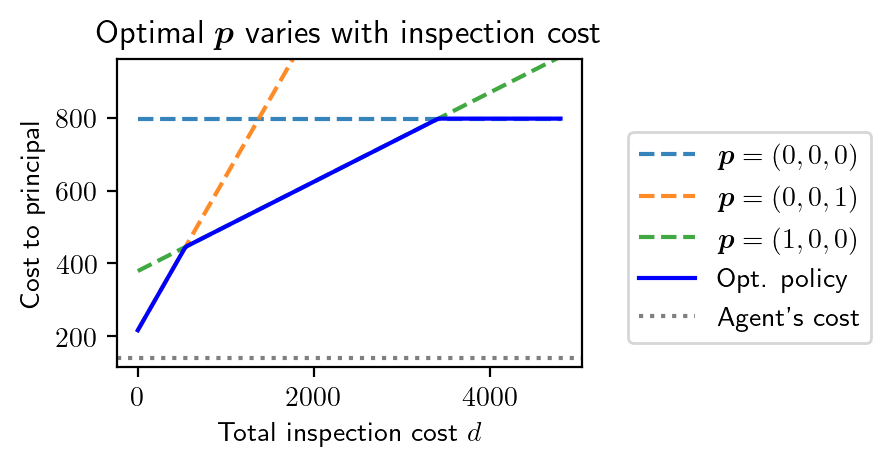

In [9]:
d_df['delta'] = d_df['d']/(m-1)
d_col = 'd'

fig,ax=plt.subplots(figsize=(3,2))
active_policies = list(
    d_df
    .pipe(best_p,[d_col])
    ['p']
    .unique()
)

for p in itertools.product([0,1],repeat=s):
    if p not in active_policies:
        continue
    (
        d_df
        [d_df['p']==p]
        .set_index(d_col)
        ['obj']
        .plot.line(
            ax=ax,
            label=f'$\\bp={p}$',
            ls='--',
            alpha=0.9,
        )
    )

(
    d_df
    .groupby(d_col)['obj']
    .min()
    .plot.line(
        ax=ax,
        label='Opt. policy',
        color='b',
    )
)
ax.axhline(
    c[-1],
    label='Agent\'s cost',
    c='tab:gray',
    ls=':',
)
ax.legend(loc=(1.1,0.08))
ax.set(
    xlabel='Total inspection cost $d$',
    # xlabel='Inspection cost $d$',
    ylabel='Cost to principal',
    ylim=(None,960),
    title='Optimal $\\bp$ varies with inspection cost'
)

## Information design optimization

In [10]:
s_vec = np.arange(2,7)
m_vec = np.arange(2,25,2)

tradeoff_df = pd.concat([
    brute_solve(
        q0 = np.vstack([
            binom.pmf(k=np.arange(s), n=s-1, p=prop)
            for prop in mu
        ]),
        q = [
            np.vstack([
                binom.pmf(k=np.arange(m), n=m-1, p=prop)
                for prop in mu
            ])
        ]*s,
        s=s,
        m=m,
        d=delta*(m-1),
    ).assign(
        adjusted_obj=lambda df: df['obj'] + delta*(s-1)
    )
    for s in s_vec
    for m in m_vec
])


heat = (
    tradeoff_df
    .pipe(best_p, ['s','m'], 'adjusted_obj')
    .pivot(
        index='s',
        columns='m',
        values='adjusted_obj',
    )
    .to_numpy()
    # .style.background_gradient(axis=None)
)
print(heat.min(), heat.max())

(
    tradeoff_df
    .pipe(best_p, ['s','m'], 'adjusted_obj')
    .sort_values('adjusted_obj')
).head()

problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
problem.py:1539: UserWarning: Solution may be inaccu

659.6115215215746 1286.3282655037426


problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


,index,p,t,t_support,obj,s,m,d,adjusted_obj
280,8,"(1, 0, 0, 0)","[17718.462084503284, 2587.8944871999042, 0.131...",3,284.611522,4,18,2125.0,659.611522
100,4,"(1, 0, 0)","[1.9523611018236513, 0.05106992654693339, 0.00...",1,420.188181,3,14,1625.0,670.188181
264,8,"(1, 0, 0, 0)","[11970.942255185275, 0.1982467479340775, 0.022...",2,296.664485,4,16,1875.0,671.664485
296,8,"(1, 0, 0, 0)","[28989.037823320738, 2678.6721024013286, 314.5...",5,299.876192,4,20,2375.0,674.876192
108,4,"(1, 0, 0)","[386.10164545664054, 0.002498136531346019, 0.0...",2,426.458712,3,16,1875.0,676.458712


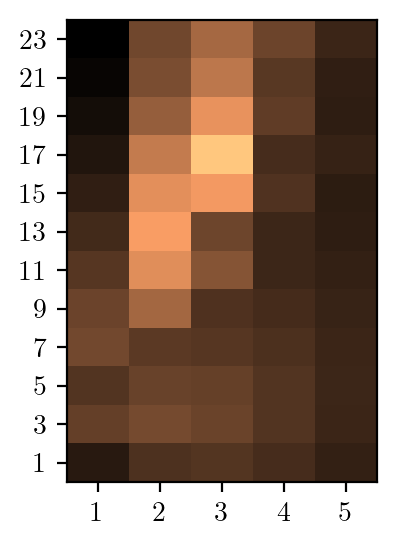

In [11]:
fig,ax=plt.subplots(figsize=(2,3))
ds = s_vec[1]-s_vec[0]
dm = m_vec[1]-m_vec[0]
ax.imshow(
    np.log(heat[:,::-1].T/heat.min()-0.99),
    extent=[s_vec.min()-ds/2-1, s_vec.max()+ds/2-1, m_vec.min()-dm/2-1, m_vec.max()+dm/2-1],
    aspect='auto',
    cmap='copper_r'
)
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=2, offset=1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=1, offset=1))

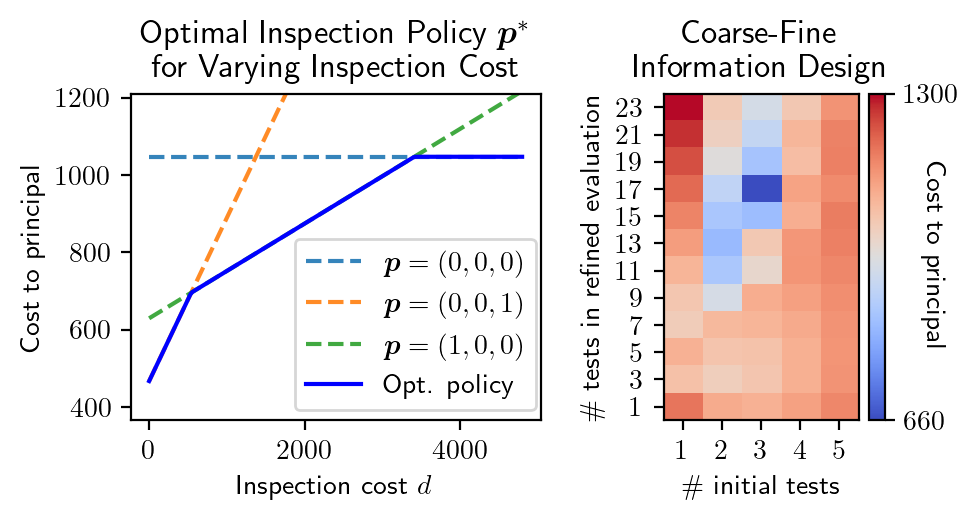

In [12]:
fig,axs=plt.subplots(
    1,2,
    constrained_layout={
        'h_pad':1e-1,
        'w_pad':0.1,
    },
    figsize=(4.9,2.6),
    width_ratios=[2.1,1],
)

ax = axs[0]
active_policies = list(
    d_df
    .pipe(best_p,[d_col])
    ['p']
    .unique()
)

for p in itertools.product([0,1],repeat=s):
    if p not in active_policies:
        continue
    (
        d_df
        [d_df['p']==p]
        .set_index(d_col)
        ['obj']
        .pipe(lambda x: x+delta*(s-1))
        .plot.line(
            ax=ax,
            label=f'$\\bp={p}$',
            # label=None,
            ls='--',
            alpha=0.9,
        )
    )

(
    d_df
    .groupby(d_col)['obj']
    .min()
    .pipe(lambda x: x+delta*(s-1))
    .plot.line(
        ax=ax,
        label='Opt. policy',
        color='b',
    )
)
ax.legend(loc=(0.4,0.03))
ax.set(
    xlabel='Inspection cost $d$',
    ylabel='Cost to principal',
    ylim=(None,960+250),
    title='Optimal Inspection Policy $\\bp^*$\nfor Varying Inspection Cost'
)


ax = axs[1]

ds = s_vec[1]-s_vec[0]
dm = m_vec[1]-m_vec[0]
cb_range = [660,1300]
im = ax.imshow(
    heat[:,::-1].T,
    extent=[s_vec.min()-ds/2-1, s_vec.max()+ds/2-1, m_vec.min()-dm/2-1, m_vec.max()+dm/2-1],
    aspect='auto',
    cmap='coolwarm',
    norm=matplotlib.colors.PowerNorm(
        vmin=cb_range[0], vmax=cb_range[1],
        gamma=0.3,
    ),
)
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=2, offset=1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=1, offset=1))
cbar =plt.colorbar(im)
cbar.set_label('Cost to principal',rotation=270, labelpad=-5)
cbar.ax.set_yticks(cb_range)

ax.set(
    title='Coarse-Fine\nInformation Design',
    xlabel='\\# initial tests',
    ylabel='\\# tests in refined evaluation',
)

fig.savefig('./output/swebench.pdf')

## Beta-binomial

0.009900990099009901
0.5


events.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


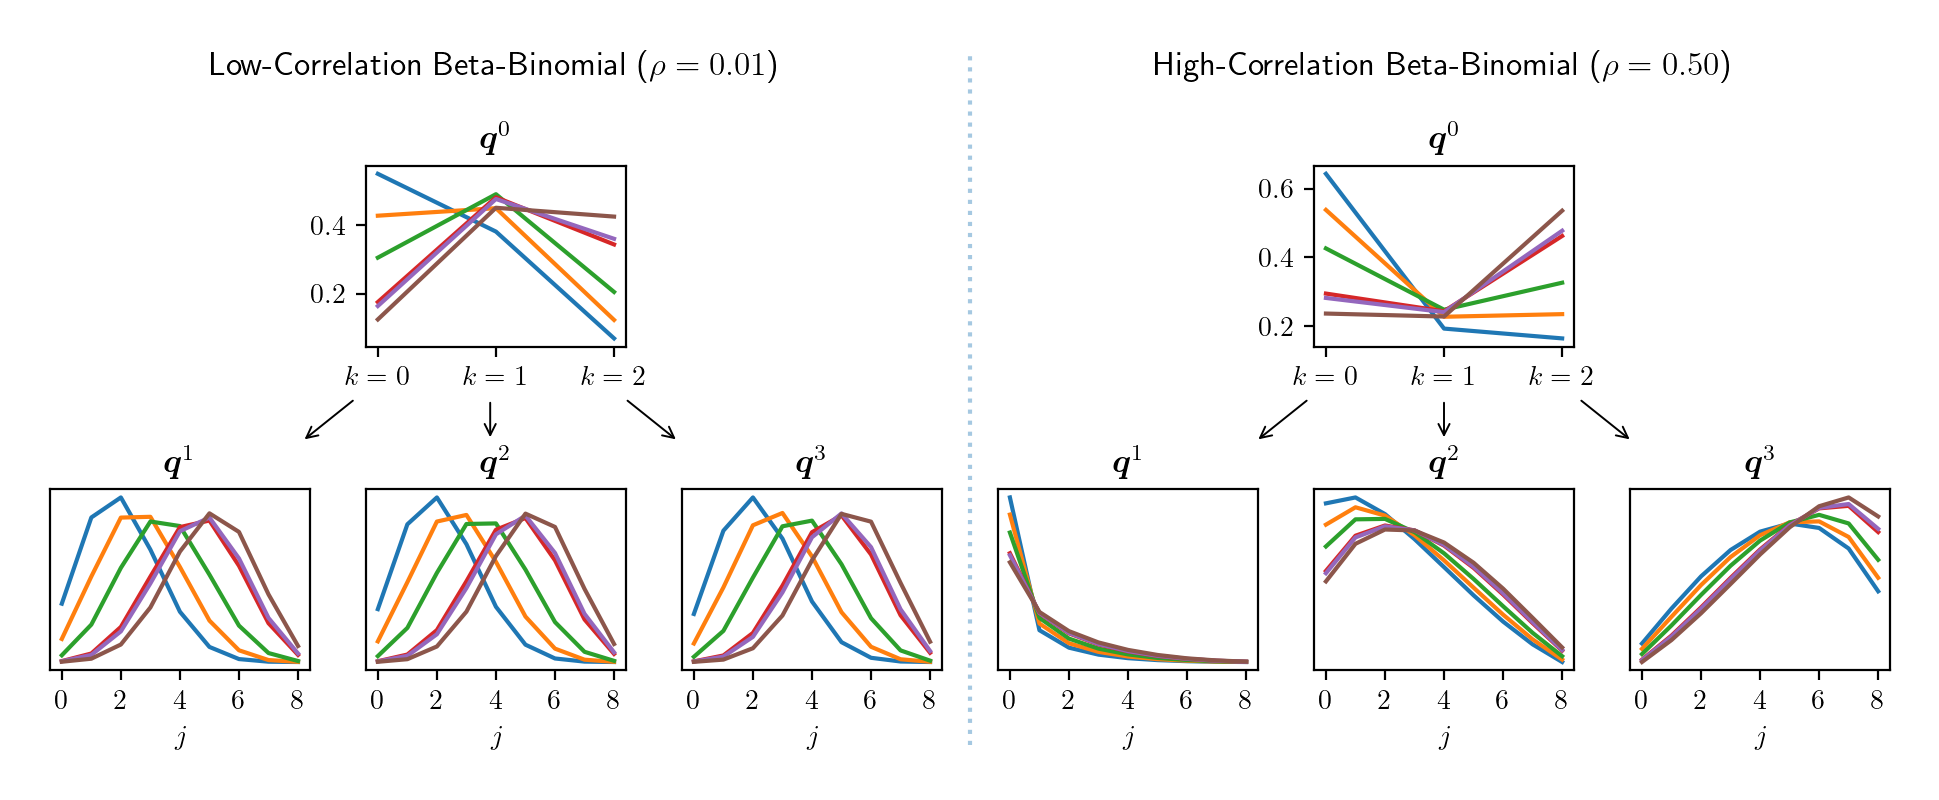

In [13]:
fig=plt.figure(figsize=(9.5,3.8), tight_layout={'h_pad':2,'w_pad':0.05})
arrowprops=dict(arrowstyle='->',lw=0.7)

overlay_ax = fig.add_axes([0,0,1,1], facecolor=(1,1,1,0))
overlay_ax.set_axis_off()
arrow = lambda xy1, xy2: overlay_ax.annotate(
    '', xytext=xy1, xy=xy2, arrowprops=arrowprops, zorder=-1,
    xycoords='figure fraction',
    textcoords='figure fraction',
)

for i, betabinom_alpha in enumerate([100,1]):
    betabinom_a_vec = mu*betabinom_alpha
    betabinom_b_vec = (1-mu)*betabinom_alpha
    rho = 1/(1+betabinom_alpha)
    print(rho)
    betabinom_q0 = np.vstack([
        betabinom.pmf(k=np.arange(s), n=s-1, a=a, b=b)
        for a,b in zip(betabinom_a_vec, betabinom_b_vec)
    ])
    betabinom_q = [
        np.vstack([
            betabinom.pmf(k=np.arange(m), n=m-1, a=k+a, b=s-k+b)
            for a,b in zip(betabinom_a_vec, betabinom_b_vec)
        ])
        for k in range(s)
    ]

    ax = fig.add_subplot(2,6,2+3*i)
    ax.plot(np.arange(s),betabinom_q0.T)
    ax.set(
        title=f'{["Low","High"][i]}-Correlation Beta-Binomial ($\\rho={rho:.2f}$)\n\n$\\bq^0$',
        # xlabel='$k$',
    )
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=1, offset=0))
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f'$k={x:.0f}$'))

    for k,qk in enumerate(betabinom_q):
        ax = fig.add_subplot(2,6,6+1+k + 3*i)
        ax.plot(qk.T)
        ax.set(
            title=f'$\\bq^{{{k+1}}}$',
            xlabel='$j$',
        )
        ax.set_yticks([])
        ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=2, offset=0))
        x_offset = 0.258 + 0.502*i
        arrow(
            (x_offset+0.07*(k-1),0.53),
            (x_offset+0.1*(k-1),0.47),
        )


overlay_ax.plot([0.5,0.5],[0,1],ls=':',alpha=0.4)


In [14]:
betabinom_alpha = 1000 # a+b
betabinom_a_vec = mu*betabinom_alpha
betabinom_b_vec = (1-mu)*betabinom_alpha

betabinom_q0 = np.vstack([
    betabinom.pmf(k=np.arange(s), n=s-1, a=a, b=b)
    for a,b in zip(betabinom_a_vec, betabinom_b_vec)
])
betabinom_q = [
    np.vstack([
        betabinom.pmf(k=np.arange(m), n=m-1, a=k+a, b=s-k+b)
        for a,b in zip(betabinom_a_vec, betabinom_b_vec)
    ])
    for k in range(s)
]

betabinom_q0 - q0

array([[ 0.00019221, -0.00038442,  0.00019221],
       [ 0.00022667, -0.00045334,  0.00022667],
       [ 0.00024725, -0.00049451,  0.00024725],
       [ 0.0002427 , -0.0004854 ,  0.0002427 ],
       [ 0.00024016, -0.00048031,  0.00024016],
       [ 0.00022727, -0.00045455,  0.00022727]])

In [15]:
rho_vec = np.linspace(0.01, 0.99)
betabinom_results_lst = []

for rho in rho_vec:
    alpha = 1/rho - 1
    betabinom_alpha = alpha # a+b
    betabinom_a_vec = mu*betabinom_alpha
    betabinom_b_vec = (1-mu)*betabinom_alpha
    betabinom_q0 = np.vstack([
        betabinom.pmf(k=np.arange(s), n=s-1, a=a, b=b)
        for a,b in zip(betabinom_a_vec, betabinom_b_vec)
    ])
    betabinom_q = [
        np.vstack([
            betabinom.pmf(k=np.arange(m), n=m-1, a=k+a, b=s-k+b)
            for a,b in zip(betabinom_a_vec, betabinom_b_vec)
        ])
        for k in range(s)
    ]
    for p in itertools.product([0,1],repeat=s):
        res = contract_optimization.DiscreteInspectionContractOptimizer.solve_for_fixed_p(
            q0=betabinom_q0,
            q=betabinom_q,
            c=c,
            d=np.ones(s)*d,
            p=p,
            target=-1,
        )
        betabinom_results_lst.append({
            'p': p,
            'p_support': sum(p),
            'd': d,
            'alpha': alpha,
            'rho': 1/(1+alpha),
            't': res[0],
            'support': (res[0]/res[0].max()>=1e-4).sum(),
            'obj': res[1],
            'modified_obj': res[1]+delta*(s-1),
        })

betabinom_results_df = pd.DataFrame(betabinom_results_lst)

(
    betabinom_results_df
    .pipe(best_p, ['alpha'])
    .sort_values('rho')
    # .set_index('rho')
    .head()
)

,index,p,p_support,d,alpha,rho,t,support,obj,modified_obj
4,4,"(1, 0, 0)",1,1000,99.000000,0.01,"[0.0003079108852537333, 1.0957253504990832e-05...",1,531.102669,781.102669
12,12,"(1, 0, 0)",1,1000,32.333333,0.03,"[3.10409619412844e-05, 1.1317535530995531e-05,...",1,592.166170,842.166170
20,20,"(1, 0, 0)",1,1000,19.000000,0.05,"[1.2120988013250508e-05, 1.9736815412507752e-0...",1,656.674081,906.674081
25,25,"(0, 0, 1)",1,1000,13.285714,0.07,"[4.0863815445553804e-07, -2.6351977814358326e-...",1,720.159202,970.159202
33,33,"(0, 0, 1)",1,1000,10.111111,0.09,"[1.690980836814233e-08, -1.3351533466536102e-0...",1,742.357658,992.357658


In [16]:
(
    betabinom_results_df
    .pipe(best_p, ['alpha'])
    ['p']
    .value_counts()
)

p
(0, 0, 0)    34
(0, 0, 1)    13
(1, 0, 0)     3
Name: count, dtype: int64

[Text(0.5, 1.0, 'Expected Pay Under Beta-Binomial Correlation'),
 Text(0.5, 0, 'Correlation coefficient $\\rho$'),
 Text(0, 0.5, 'Cost to principal'),
 (130.0431102142627, 2600.0)]

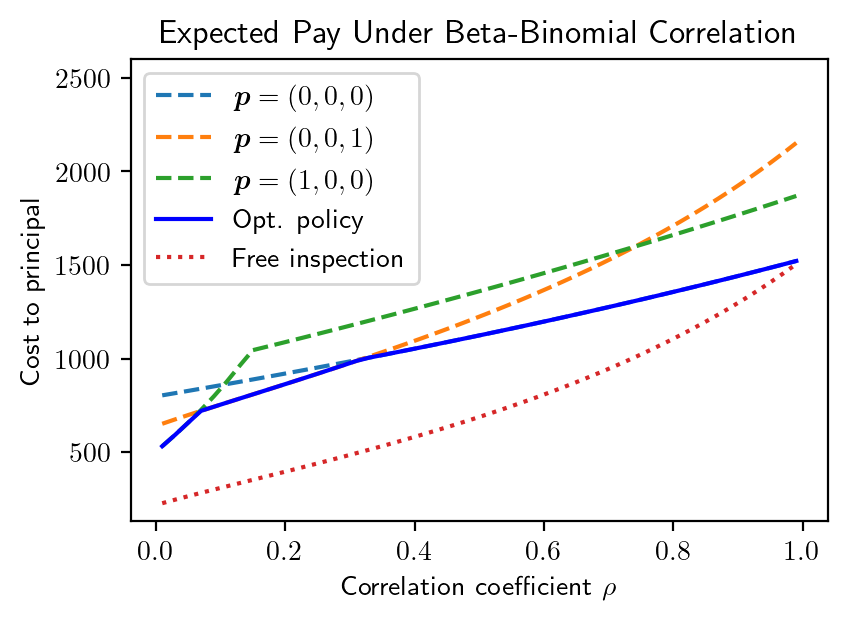

In [17]:
fig,ax=plt.subplots(figsize=(4.5,3))



for p in itertools.product([0,1],repeat=s):
    if p not in [(0,0,1),(1,0,0),(0,0,0)]:
        continue
    (
        betabinom_results_df
        .pipe(lambda df: df.loc[df['p']==p])
        .set_index('rho')
        ['obj']
        .plot.line(
            ax=ax,
            ls='--',
            label=f'$\\bp={p}$',
        )
    )

(
    betabinom_results_df
    .pipe(best_p, ['alpha'])
    .set_index('rho')
    ['obj']
    .plot.line(
        ax=ax,
        c='b',
        label='Opt. policy',
    )
)

(
    betabinom_results_df
    .pipe(lambda df: df.loc[df['p']==(1,1,1)])
    .set_index('rho')
    ['obj']
    .map(lambda x: x-1000)
    .plot.line(
        ax=ax,
        ls=':',
        label='Free inspection',
    )
)

ax.legend()

ax.set(
    title='Expected Pay Under Beta-Binomial Correlation',
    xlabel='Correlation coefficient $\\rho$',
    ylabel='Cost to principal',
    ylim=(None,2600)
)



## Dirichlet

In [18]:
from cvxpy import SolverError
is_mlrp = lambda qk: bool((np.diff(qk[:-1]/(qk[-1]+1e-9),axis=1)<=0).all())

rng = np.random.default_rng(1)

def dirichlet_noise(q,alpha):
    return np.vstack([
        rng.dirichlet(q[i]*alpha)
        for i in range(len(q))
    ])

dirichlet_results_lst = []
alpha_vec = np.geomspace(1,1e6,20)

for rep in tqdm(range(100)):
    for alpha in alpha_vec:
        noisy_q0 = dirichlet_noise(q0, alpha=alpha)
        noisy_q=[dirichlet_noise(q1, alpha=alpha) for k in range(s)]
        for p in itertools.product([0,1],repeat=s):
            try:
                res = contract_optimization.DiscreteInspectionContractOptimizer.solve_for_fixed_p(
                    q0=noisy_q0,
                    q=noisy_q,
                    c=c,
                    d=np.ones(s)*d,
                    p=p,
                    target=-1,
                )
            except RuntimeError:
                continue
            except SolverError:
                continue
            dirichlet_results_lst.append({
                'rep': rep,
                'p': p,
                'd': d,
                'alpha': alpha,
                'mlrp_signal': is_mlrp(noisy_q0),
                'mlrp_outcome': all(is_mlrp(qk) for qk in noisy_q),
                'mlrp': all(is_mlrp(qk) for qk in noisy_q + [noisy_q0]),
                't': res[0],
                'support': (res[0]/res[0].max()>=1e-4).sum(),
                'p_support': sum(p),
                'obj': res[1],
                'modified_obj': res[1]+delta*(s-1),
            })

dirichlet_results_df = pd.DataFrame(dirichlet_results_lst)


100%|██████████| 100/100 [00:31<00:00,  3.16it/s]


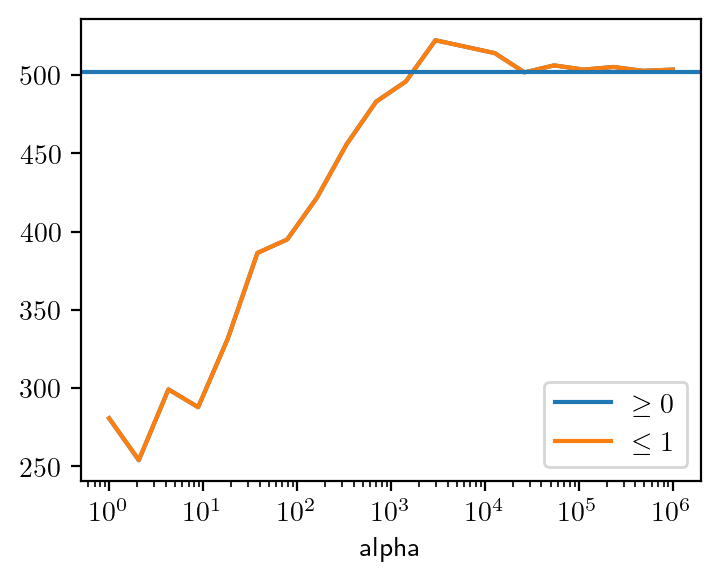

In [19]:
fig,ax=plt.subplots(figsize=(4,3))
for fltr in ['>=0','<=1']:
    label = fltr.replace(">=","\\ge").replace("<=","\\le")
    (
        dirichlet_results_df
        .query(f'p_support{fltr}')
        .pipe(best_p, ['alpha','rep'])
        .assign(alpha_inv=lambda df: df['alpha'].map(lambda x: 1/x))
        .groupby('alpha')
        ['obj']
        .mean()
        .plot.line(
            ax=ax,
            logx=True,
            # logy=True,
            label=f'${label}$',
        )
        # ['obj']
        # .assign(p_support=lambda df: df['p'].map(sum))
    )
ax.legend()

ax.axhline(brute_solve()['obj'].min(), )

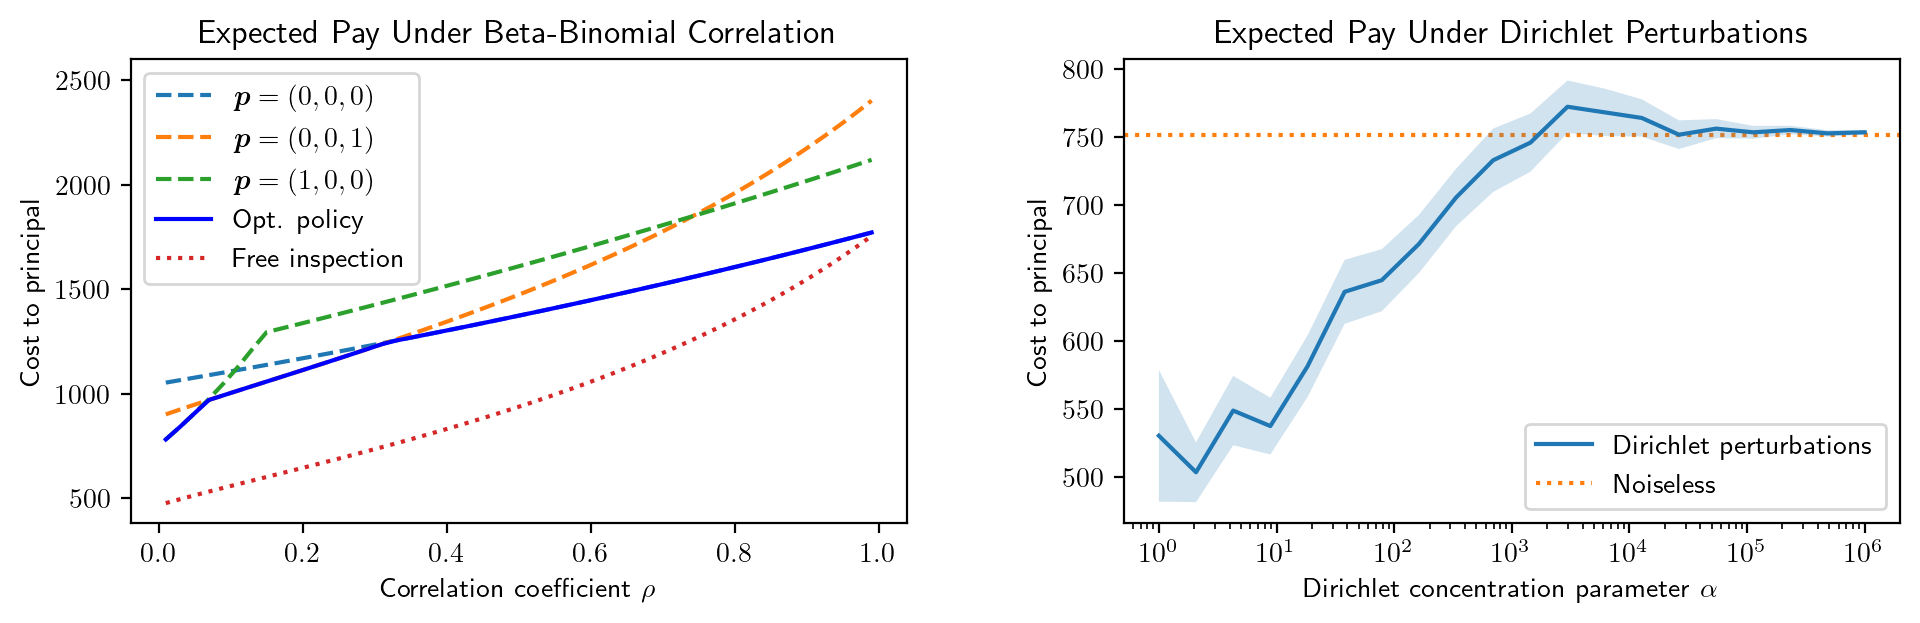

In [20]:
fig,axs=plt.subplots(1,2,figsize=(10,3),constrained_layout={'w_pad':0.3})

def mean_confidence_interval(data, confidence=0.95):
    # https://stackoverflow.com/questions/15033511/compute-a-confidence-interval-from-sample-data
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

ax = axs[0]
for p in itertools.product([0,1],repeat=s):
    if p not in [(0,0,1),(1,0,0),(0,0,0)]:
        continue
    (
        betabinom_results_df
        .pipe(lambda df: df.loc[df['p']==p])
        .set_index('rho')
        ['modified_obj']
        .plot.line(
            ax=ax,
            ls='--',
            label=f'$\\bp={p}$',
        )
    )

(
    betabinom_results_df
    .pipe(best_p, ['alpha'])
    .set_index('rho')
    ['modified_obj']
    .plot.line(
        ax=ax,
        c='b',
        label='Opt. policy',
    )
)

(
    betabinom_results_df
    .pipe(lambda df: df.loc[df['p']==(1,1,1)])
    # .query('p==(1,0,0)')
    .set_index('rho')
    ['modified_obj']
    .map(lambda x: x-1000)
    .plot.line(
        ax=ax,
        ls=':',
        label='Free inspection',
    )
)

ax.legend()

ax.set(
    title='Expected Pay Under Beta-Binomial Correlation',
    xlabel='Correlation coefficient $\\rho$',
    ylabel='Cost to principal',
    ylim=(None,2600)
)
# ax.axhline(brute_solve()['obj'].min()+delta*(s-1), label='Noiseless', color='tab:pink', zorder=-1, linestyle=':')


ax = axs[1]
(
    dirichlet_results_df
    .pipe(best_p, ['alpha','rep'])
    .groupby('alpha')
    ['modified_obj']
    .agg(mean_confidence_interval)
    .apply(pd.Series)
    .rename({0:'mean',1:'ci_low',2:'ci_high'},axis=1)
    .pipe(lambda df: (
        df['mean'].plot.line(ax=ax, label='Dirichlet perturbations'),
        ax.fill_between(df.index, df['ci_low'], df['ci_high'], alpha=0.2),
    ))
)

ax.set(
    xlabel='Dirichlet concentration parameter $\\alpha$',
    ylabel='Cost to principal',
    title='Expected Pay Under Dirichlet Perturbations',
    xscale='log',
)

ax.axhline(brute_solve()['obj'].min()+delta*(s-1), label='Noiseless', color='tab:orange', zorder=-1, linestyle=':')
ax.legend()

fig.savefig('./output/simplicity_robustness.pdf')
